## Week 4: Lenard-Jones Forces

In [1]:
#libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

In [2]:
#Code from project 3

def VerletMDEngine_2d(initial_pos, initial_vel, kx=1, ky=1, snapshots=50, m=1, dt_step = 0.001):

    time = np.arange(snapshots, dtype=float) * dt_step 

    energy = np.zeros(snapshots, dtype=float)

    #x_step = np.zeros(snapshots, dtype=float) ; v_step = np.zeros(snapshots, dtype=float)

    x_2d = np.zeros((snapshots, 2), dtype=float) ; v_2d = np.zeros((snapshots, 2), dtype=float)
    force_2d = np.zeros((snapshots,2), dtype=float)

    x = np.array(initial_pos) ; v = np.array(initial_vel) ; ke_list = np.zeros(snapshots, dtype=float)
    #v_halfstep = float(initial_vel)

    #k = float(potential_e) 

    x_2d[0] = np.array(initial_pos, dtype=float)
    v_2d[0] = np.array(initial_vel, dtype=float)

    k_2d = np.array([kx, ky], dtype=float) 
    
    F = -k_2d * x

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2)
    ke_0 = 0.5 * m * np.power(v, 2)
    energy[0] = pe_0.sum() + ke_0.sum()
    ke_list[0] = ke_0.sum()

    #--------------------- New stuff
    particles = 1
    boltzmann = 1 #1.380649e-23 
    gamma = 0.1 #friction
    target_temp = 1.0
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / m) #
    force_random = np.sqrt(dt_step) * sigma * np.random.normal(size=2)
    rand = np.random.default_rng()



    for i in range(1, snapshots): #vectorized

        #random_number = rand.normal(size=2) didnt need
        force_random = np.sqrt(dt_step) * sigma * np.random.normal(size=2)
        
        #v_halfstep = v + ((1/(2*m)) * F * dt_step)
        
        v_halfstep = v + (((F/m) - gamma * v) * (dt_step/2)) + force_random/2 #New equation for halfstep
        x_next = x + (v_halfstep * dt_step)
        f_next = -k_2d * x_next
        v_next = v_halfstep + + (((f_next / m) - gamma * v_halfstep) * (dt_step / 2.0)) + 0.5 * force_random #still working on

        x_2d[i] = x_next
        v_2d[i] = v_next
        force_2d[i] = f_next


        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)
        ke_list[i] = ke.sum()

        energy[i] = pe.sum() + ke.sum()

        x = x_next ; v = v_next ; F = f_next


    
    temperature = np.zeros(v_2d.size, dtype=float)
    dimensions = v_2d.shape[1]

    temperature = (ke_list * 2) / (boltzmann * dimensions * particles)



    return time, x_2d, v_2d, energy, temperature



pos_1 = [0.0,1.0] ; vel_1 = [0.5,1.0] ; kx = 1.0 ; ky = 1.0 ; m=1 ; 

# ^^ To set parameters ^^

dt=0.01
omega = np.sqrt(kx/m)
timestep = dt*omega

time = 5.0
snapshots = int(time / timestep)

time, x, v, energy, temp = VerletMDEngine_2d(pos_1, vel_1, kx=1, ky=1, snapshots = snapshots, m=1, dt_step = timestep)

In [3]:
#Fixed up code based on project 3

def OneParticleEngine(initial_pos, initial_vel, kx=1, ky=1, m=1, particles=1, dt=0.001, time=5):
    dimensions = 2

    omega = np.sqrt(kx/m) ; timestep = dt*omega
    snapshots = int(time / timestep)

    time = np.arange(snapshots, dtype=float) * timestep 
    energy = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, 2), dtype=float) ; v_2d = np.zeros((snapshots, 2), dtype=float)
    force_2d = np.zeros((snapshots,2), dtype=float)

    x = np.array(initial_pos) ; v = np.array(initial_vel) ; ke_list = np.zeros(snapshots, dtype=float)

    x_2d[0] = np.array(initial_pos, dtype=float) ; v_2d[0] = np.array(initial_vel, dtype=float)

    k_2d = np.array([kx, ky], dtype=float) ; F = -k_2d * x

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * m * np.power(v, 2)
    energy[0] = pe_0.sum() + ke_0.sum() ; ke_list[0] = ke_0.sum()

    boltzmann = 1 ; gamma = 0.1 ; target_temp = 1.0
    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / m)

    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=2)
       
        v_halfstep = v + (((F/m) - gamma * v) * (timestep/2)) + force_random/2 #New equation for halfstep
        x_next = x + (v_halfstep * timestep)
        f_next = -k_2d * x_next
        v_next = v_halfstep + + (((f_next / m) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random #still working on

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * m * np.power(v_next, 2)
        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + ke.sum()

        x = x_next ; v = v_next ; F = f_next
    
    temperature = np.zeros(v_2d.size, dtype=float)
    temperature = (ke_list * 2) / (boltzmann * dimensions * particles)

    return time, x_2d, v_2d, energy, temperature


#--------------------------------------------------------------------
#Parameters

inital_position = [0.0,1.0] ; initial_velocity = [0.5,1.0] ; kx=1.0 ; ky=1.0 ; mass=1 ; particles = 1 ; dt=0.01 ; time=5 

#--------------------------------------------------------------------

time, position, velocity, energy, temperature = OneParticleEngine(inital_position, initial_velocity, kx, ky, mass, particles, dt, time)

#### Task 1: Plot Many Particles

##### Update MD Engine to Support Multiple Particles

In [4]:
def MultiParticleEngine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, rand_position_scale=1, rand_velocity_scale=1):
    D = 2
    omega = np.sqrt(kx/mass) ; timestep = dt*omega
    snapshots = int(np.floor(total_time / timestep)) + 1

    time = np.arange(snapshots, dtype=float) * timestep 
    energy = np.zeros(snapshots, dtype=float) ; ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float) ; v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float)

#   vvv Fixed this to set random inital positions and velocities for multiple particles 
    x = rand_position_scale * np.random.rand(particles, D) ; v = rand_velocity_scale * np.random.rand(particles, D)
    
    x_2d[0] = x ; v_2d[0] = v

    k_2d = np.array([kx, ky], dtype=float) ; F = -k_2d * x

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)
    energy[0] = pe_0.sum() + ke_0.sum() ; ke_list[0] = ke_0.sum()

    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)

    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)
        f_next = -k_2d * x_next
        v_next = v_halfstep + + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)
        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + ke.sum()

        x = x_next ; v = v_next ; F = f_next
    
    temperature = np.zeros(v_2d.size, dtype=float)
    temperature = (ke_list * 2) / (boltzmann * D * particles)

    return time, x_2d, v_2d, energy, temperature, particles, timestep



time, position, velocity, energy, temperature, particles, timestep = MultiParticleEngine(
                                                                                            kx = 3.0, 
                                                                                            ky = 1.0, 

                                                                                            mass = 1.0, 
                                                                                            particles = 5,   

                                                                                            boltzmann = 1, 
                                                                                            gamma = 0.01, 
                                                                                            target_temp = 1.0, 

                                                                                            dt = 0.01, 
                                                                                            total_time = 15.0,

                                                                                            rand_position_scale = 1, 
                                                                                            rand_velocity_scale = 10)

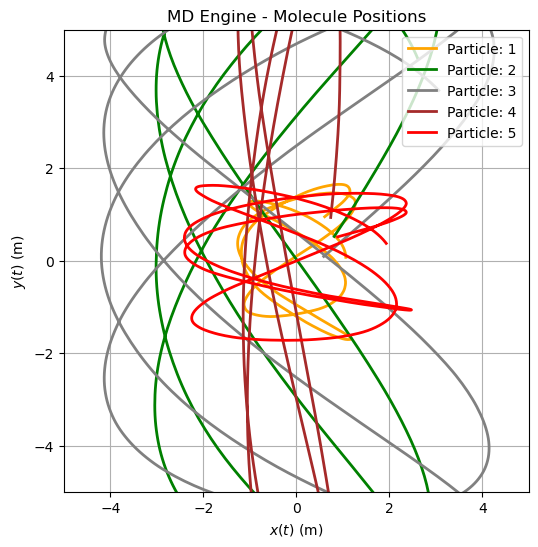

In [5]:
fig, ax = plt.subplots(1,1, figsize=(6,6))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for p in range(particles):
    if len(color_list) == 0:
        color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    #label = f"$ωΔt$ = {timestep:0.3f}"
    ax.plot(position[:,p,0], position[:,p,1], color = selected_color, linestyle = "-", linewidth=2, label = "Particle: " + str(p + 1))


ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') 
ax.set_xlim(-5, 5) ; ax.set_ylim(-5, 5)
ax.legend(loc="upper right") ; ax.set_title("MD Engine - Molecule Positions") ; ax.grid(True) ; 

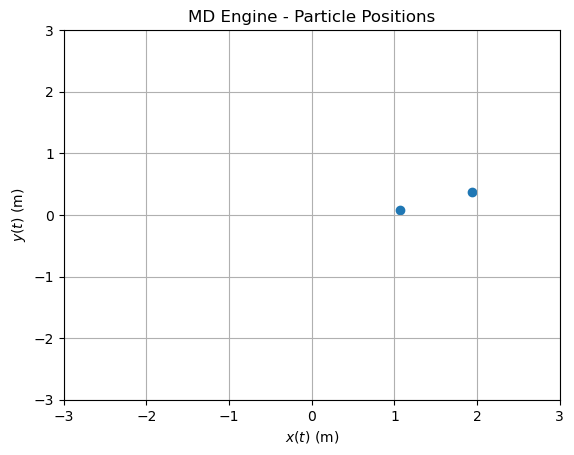

In [6]:
#Scatter plot version

# -1 take the last timestep of the particle
plt.scatter(position[-1,:,0], position[-1,:,1])

plt.xlabel('$x(t)$ (m)') ; plt.ylabel('$y(t)$ (m)') ; plt.title("MD Engine - Particle Positions")
plt.xlim(-3,3) ; plt.ylim(-3,3) ; plt.grid(True) ; plt.show()

#### Task 1.5: Animate Many Particles

##### Animate a Plot With Many Particles 

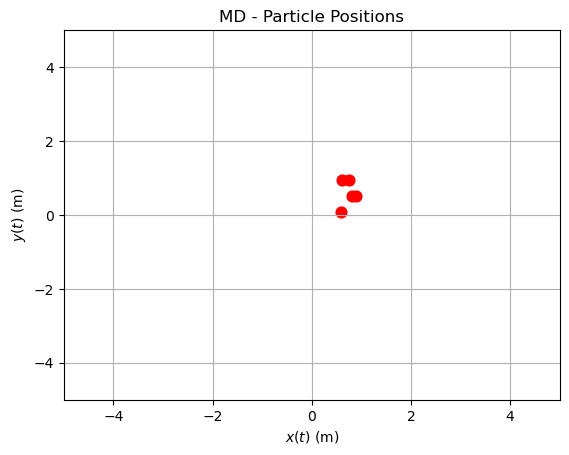

In [7]:
#color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
#random_color = np.random.choice(color_list)

fig, ax = plt.subplots()

scatter = ax.scatter(position[0,:,0], position[0,:,1], s=60, c= 'red') #size (s) color (c)

ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') ; 
ax.set_xlim(-5,5) ; ax.set_ylim(-5,5) ; ax.set_title("MD - Particle Positions") ; ax.grid(True)

def update_data(frames): #Updates particle at each frame
    scatter.set_offsets(position[frames]) #updates scatter points
    plt.pause(0.001) #it was going too fast (seconds between frames)
    return scatter,

animation = FuncAnimation(fig, update_data, frames=len(time)) ; #HTML(animation.to_jshtml())
animation.save("Many_Particles_Test.gif", writer="pillow", fps=30)

#### Task 2: Implement Lenard-Jones Potential

##### Calculus Exercise. Then Plot Timestep by U(t), and x(t) by y(t)

In [13]:
def LennardParticleEngine(kx=1, ky=1, mass=1, particles=2, boltzmann=1, gamma=0.1, target_temp=1.0, dt=0.001, total_time=5, 
                        rand_position_scale=1, rand_velocity_scale=1, epsilon = 1.0, lennard_sigma = 1.0):
    
    D = 2
    omega = np.sqrt(kx/mass) ; timestep = dt*omega
    snapshots = int(np.floor(total_time / timestep)) + 1

    time = np.arange(snapshots, dtype=float) * timestep 
    energy = np.zeros(snapshots, dtype=float) ; ke_list = np.zeros(snapshots, dtype=float)
    x_2d = np.zeros((snapshots, particles, D), dtype=float) ; v_2d = np.zeros((snapshots, particles, D), dtype=float)
    force_2d = np.zeros((snapshots, particles, D), dtype=float) ; temperature = np.zeros(v_2d.size, dtype=float)

    x = rand_position_scale * np.random.rand(particles, D) ; v = rand_velocity_scale * np.random.rand(particles, D)

    k_2d = np.array([kx, ky], dtype=float) 
    
    #-----------------------------------------------------------------------------------------
    F = -k_2d * x # old harmonic force equation
    for a in range(particles): # double loop avoids double-counting pairs
        for b in range(a + 1, particles): 
            r_vector = x[a] - x[b] # Just the displacement vector r
            r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) #scalar distance for r
            if r > 1e-12: # random very small number that stops r = 0 division or anything too close to it
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6 #computes the sigma/r to the 12th and 6th power

                lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / (r * r) #scalar prefactor
                F_part = lennard_force * r_vector #Multiplies the scalar prefactor by the displacement vector for vector F
                
                F[a] += F_part ; F[b] -= F_part # Newtons 3rd law Fij=-Fji so momentum is conserved, pairwise forces equal and opposite
    #-----------------------------------------------------------------------------------------

    x_2d[0] = x ; v_2d[0] = v ; force_2d[0] = F
    pe_0 = 0.5 * k_2d * np.power(x, 2) ; ke_0 = 0.5 * mass * np.power(v, 2)

    #-----------------------------------------------------------------------------------------
    lennard_pe_0 = 0.0 # comment info above
    for a in range(particles):
        for b in range(a + 1, particles):
            delta_x = x[a] - x[b] ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2) # r = distance between two particles, sqrt((xa-xb)^2 + (ya-yb)^2)

            if r > 1e-12:
                sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                lennard_pe_0 += (sigma_r_12 - sigma_r_6) * (epsilon/4)
    #----------------------------------------------------------------------------------------

    energy[0] = pe_0.sum() + lennard_pe_0 + ke_0.sum() ; ke_list[0] = ke_0.sum()

    sigma = np.sqrt(2 * gamma * boltzmann * target_temp / mass)

    for i in range(1, snapshots):
        force_random = np.sqrt(timestep) * sigma * np.random.normal(size=(particles, 2))
       
        v_halfstep = v + (((F/mass) - gamma * v) * (timestep/2)) + force_random/2 
        x_next = x + (v_halfstep * timestep)
        f_next = -k_2d * x_next
        #-----------------------------------------------------------------------------------------
        F = -k_2d * x # comment info above
        for a in range(particles):
            for b in range(a + 1, particles):
                r_vector = x_next[a] - x_next[b]
                r = np.sqrt(r_vector[0]**2 + r_vector[1]**2)
                if r > 1e-12:
                    sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                    lennard_force = 3.0 * epsilon * (2.0 * sigma_r_12 - sigma_r_6) / (r * r)
                    F_part = lennard_force * r_vector
                    
                    F[a] += F_part ; F[b] -= F_part
        #-----------------------------------------------------------------------------------------



        v_next = v_halfstep + (((f_next / mass) - gamma * v_halfstep) * (timestep / 2.0)) + 0.5 * force_random 

        x_2d[i] = x_next ; v_2d[i] = v_next ; force_2d[i] = f_next

        pe = 0.5 * k_2d * np.power(x_next, 2)
        ke = 0.5 * mass * np.power(v_next, 2)

        #-----------------------------------------------------------------------------------------
        lennard_pe = 0.0 # comment info above
        for a in range(particles):
            for b in range(a + 1, particles):
                delta_x = x_next[a] - x_next[b] ; r = np.sqrt(r_vector[0]**2 + r_vector[1]**2)

                if r > 1e-12:
                    sigma_r_12 = (lennard_sigma / r)**12 ; sigma_r_6 = (lennard_sigma / r)**6

                    lennard_pe += (sigma_r_12 - sigma_r_6) * (epsilon/4)
        #----------------------------------------------------------------------------------------


        ke_list[i] = ke.sum() ; energy[i] = pe.sum() + lennard_pe + ke.sum()

        x = x_next ; v = v_next ; F = f_next
    
    temperature = (ke_list * 2) / (boltzmann * D * particles)
    pe_list = energy - ke_list

    return time, x_2d, v_2d, energy, pe_list, temperature, particles, timestep



time, position, velocity, energy, potential_energy, temperature, particles, timestep = LennardParticleEngine(
                                                                                            kx = 1.0, #spring constant for x position
                                                                                            ky = 2.0, #spring constant for y position

                                                                                            mass = 1.0, #mass
                                                                                            particles = 2, # number of particles

                                                                                            boltzmann = 1, # in the surroundings at given temperature
                                                                                            gamma = 0.01, #friction
                                                                                            target_temp = 1.0, 

                                                                                            dt = 0.01, #timestep
                                                                                            total_time = 30.0, # total time

                                                                                            rand_position_scale = 1, #random P_i scalar
                                                                                            rand_velocity_scale = 5,  #random V_i scalar
                                                                                            
                                                                                            epsilon = 1, #max strength of attraction
                                                                                            lennard_sigma = 1) # radius

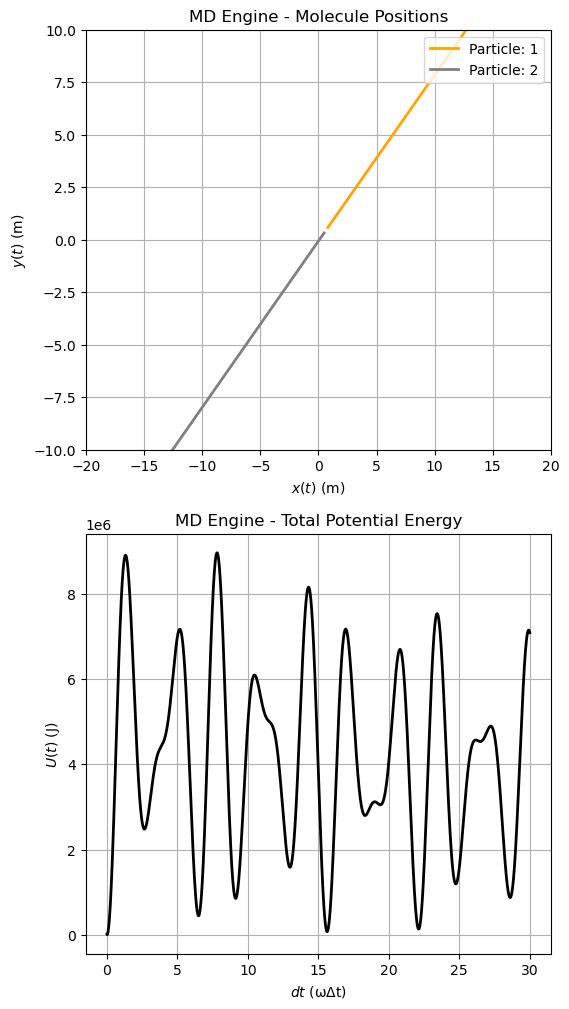

In [14]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(6,12))
color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']

for p in range(particles):
    if len(color_list) == 0:
        color_list = ['red', 'blue', 'green', 'orange', 'brown', 'gray']
    selected_color = random.choice(color_list)
    color_list.remove(selected_color)

    ax1.plot(position[:,p,0], position[:,p,1], color = selected_color, linestyle = "-", linewidth=2, label = "Particle: " + str(p + 1))

ax2.plot(time, potential_energy, color = 'black', linestyle = "-", linewidth=2)



ax1.set_xlabel('$x(t)$ (m)') ; ax1.set_ylabel('$y(t)$ (m)') 
ax1.set_xlim(-20, 20) ; ax1.set_ylim(-10, 10)
ax1.legend(loc="upper right") ; ax1.set_title("MD Engine - Molecule Positions") ; ax1.grid(True) ; 

ax2.set_xlabel('$dt$ (ωΔt)') ; ax2.set_ylabel('$U(t)$ (J)') 
#ax2.set_xlim(-10, 10) ; ax2.set_ylim(-10, 10) ; ax2.legend(loc="upper right") 
ax2.set_title("MD Engine - Total Potential Energy") ; ax2.grid(True) ; 

#the spikes for U(t) represent 2 particles getting super close and potential energy shooting up

#### Task 2.5: Animate Lenard-Jones Potential Upgrade

##### Animate x(t) y(t)

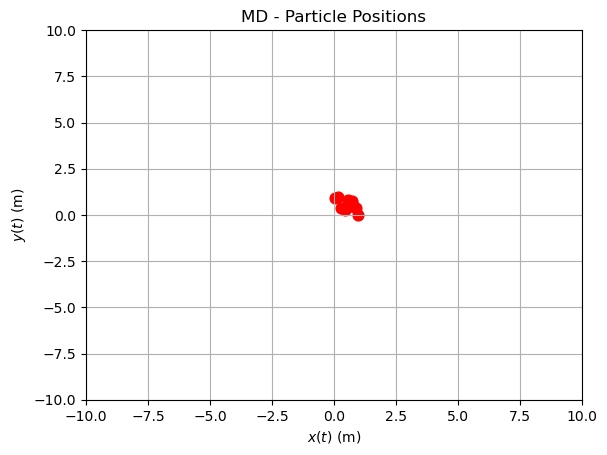

In [10]:
fig, ax = plt.subplots()

scatter = ax.scatter(position[0,:,0], position[0,:,1], s=60, c= 'red') #size (s) color (c)

ax.set_xlabel('$x(t)$ (m)') ; ax.set_ylabel('$y(t)$ (m)') ; 
ax.set_xlim(-10,10) ; ax.set_ylim(-10,10) ; ax.set_title("MD - Particle Positions") ; ax.grid(True)

def update_data(frames): #Updates particle at each frame
    scatter.set_offsets(position[frames]) #updates scatter points
    return scatter,
    

animation = FuncAnimation(fig, update_data, frames=len(time)) ; #HTML(animation.to_jshtml())
animation.save("Lennard_Particles_Test.gif", writer="pillow", fps=30)